In [8]:
from MLPKAN import MLPKAN
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time

In [9]:
seed = 500
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

MLPKANmodel = MLPKAN([2, 3, 1], subnetwork_shape=[5])


In [10]:
# f = lambda x: x[:, 0]**2 + x[:, 1]**2
# # f = lambda x: torch.sin(x[:, 0]**2 + 3*x[:, 1])
# # f = lambda x: torch.tanh(torch.exp(x[:, 0] + x[:,1]**4) - (1/x[:,0]))
# # f = lambda x: (1/(x[:, 0]**2 + x[:, 1]**2 + 1)) + x[:, 0]**3 - x[:, 1]**3
# dataset = create_dataset(f, n_var=2, normalize_input=True, seed=seed)

train_path = Path('../feynmanDataset/train/I.12.1_train.csv')
test_path = Path('../feynmanDataset/test/I.12.1_test.csv')


train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)
X_train = torch.tensor(train_df.iloc[:, :-1].values, dtype=torch.float32)
y_train = torch.tensor(train_df.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(test_df.iloc[:, :-1].values, dtype=torch.float32)
y_test = torch.tensor(test_df.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)
dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}

In [11]:
t0 = time.perf_counter()
histories = MLPKANmodel.fit(dataset,steps=300, lr=0.001, early_stop=True)
t1 = time.perf_counter() - t0
print(t1)

Epoch 126/300, RMSE: 0.0319, R2: 0.9901 
Early stopping at epoch 126 with R2: 0.9901
1.8341146999737248


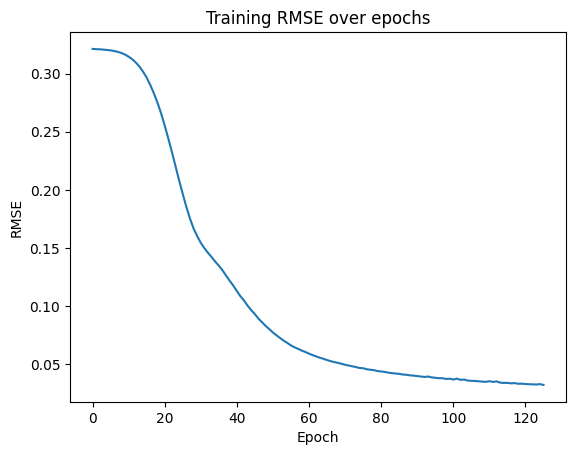

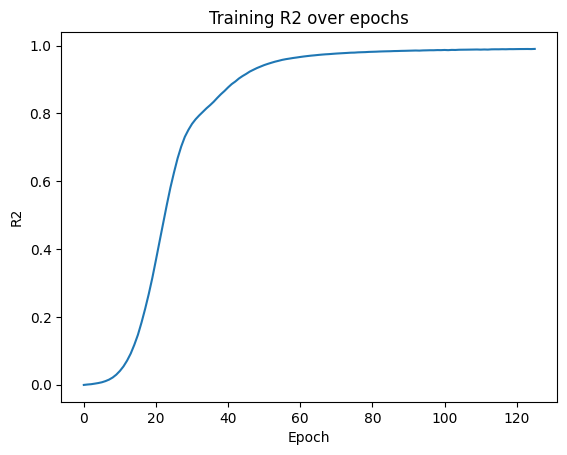

In [12]:
plt.plot(histories['rmse_history'])
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training RMSE over epochs')
plt.show()

plt.plot(histories['R2_history'])
plt.xlabel('Epoch')
plt.ylabel('R2')
plt.title('Training R2 over epochs')
plt.show()


In [13]:
def R2(preds, targets):
            """
            Coefficient of Determination (R²).
            Note: R² can be negative if predictions are worse than the mean baseline.
            R² = 1 - (SS_res / SS_tot)
            """
            pred_mean = torch.mean(preds, dim=0, keepdim=True)
            target_mean = torch.mean(targets, dim=0, keepdim=True)
            SS_res = torch.sum((targets - preds)**2, dim=0)
            SS_tot = torch.sum((targets - target_mean)**2, dim=0)
            r2_score = 1 - (SS_res / (SS_tot + 1e-8))
            return torch.nan_to_num(r2_score)

pred = MLPKANmodel.forward(dataset['train_input'])
R2_score = R2(pred, dataset['train_label']).item()
pred2 = MLPKANmodel.forward(dataset['test_input'])
R2_score2 = R2(pred2, dataset['test_label']).item()
print("R2 score train:", R2_score, "R2 score test:", R2_score2)

R2 score train: 0.9897637963294983 R2 score test: 0.9901162385940552
